# Plane Poiseuille flow between no-slip plates

A channel of width $W$ between two plates, periodic along $x$, driven by a body force $f$. The steady solution is the parabola

$$u(y) = \frac{f\,y\,(W-y)}{2\nu},\qquad u_{\max}=\frac{fW^2}{8\nu},$$

and the plates carry all of the momentum put in by the force: the load on the two plates equals $\rho f\,W L$.

This tests the **no-slip wall closure** on a flat wall: a closure that is too weak flattens the profile, one that is too strong sharpens it. The plates are exact analytic walls (`BoxRep` bodies spanning
the periodic box): no wall particles. The same description runs with both solvers (`SCHEME`), see notebook 01.

In [1]:
SCHEME = "delta"      # "delta" | "dfsph"
QUALITY = "quick"     # "quick" | "full"
DEVICE = "cuda:0"

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import warpSPHBoundaries  # noqa: F401
from warpSPHBoundaries.scene.periodic import Periodic
from warpSPHBoundaries.scene.scene import Body, BoxRep, Scene
from warpSPHBoundaries.sim.references import poiseuille
from warpSPHBoundaries.sim.solvers import make_solver, box_lattice

n = {"quick": 32, "full": 48}[QUALITY]               # particles per unit length (the box is 1 long)
ny = {"quick": 16, "full": 24}[QUALITY]              # rows across the channel
nu, f = 0.0185, 0.05
T = {"quick": 9.0, "full": 12.0}[QUALITY]
dx = 1.0 / n

## Set-up
`box_lattice` puts the first row of particles at the distance from the wall that the scheme's lattice calibration prescribes (half a spacing for `delta`, 0.55 dx for `dfsph`), so the channel width $W$
differs between the schemes by a fraction of a spacing; the reference uses the actual $W$.

In [3]:
pos, hi = box_lattice(SCHEME, (0, 0), (n, ny), dx, walls=(False, True))
W = hi[1]
plate = lambda yc, i: Body(bodyId=i, center=(0.5, yc), reps=[BoxRep((-0.8, -0.15), (0.8, 0.15))])      # 1.6 x 0.3 plates: longer than the box, so each is periodic
scene = Scene([plate(-0.15, 0), plate(W + 0.15, 1)], DEVICE)
umax = f * W * W / (8 * nu)
extra = {"maxDt": 5e-3} if SCHEME == "dfsph" else {}
sol = make_solver(SCHEME, pos, dx, scene, nu=nu, bodyForce=(f, 0.0), periodic=Periodic((0, -9), (1, 9), (True, False)), c0=10 * umax, device=DEVICE, **extra)
print(f"scheme {SCHEME}: N = {sol.n}, W = {W:.4f}, u_max = {umax:.4f}, Re = u_max W / nu = {umax * W / nu:.2f}")

mean_u, load = [], []
def record(s):
    mean_u.append((s.time, float(s.v[:, 0].mean()) / (2 * umax / 3)))
    load.append(s.loads(0)[0] + s.loads(1)[0])

scheme delta: N = 512, W = 0.5000, u_max = 0.0845, Re = u_max W / nu = 2.28


## Integration

In [4]:
sol.run(T, every=T / 4, callback=record, report=lambda s: f"<u>/<u>_exact {mean_u[-1][1]:.4f}")

  t    2.253  dt 1.00e-02  vmax    0.067  <u>/<u>_exact 0.8003  [4 s]


  t    4.503  dt 1.00e-02  vmax    0.080  <u>/<u>_exact 0.9536  [9 s]


  t    6.753  dt 1.00e-02  vmax    0.083  <u>/<u>_exact 0.9835  [22 s]


  t    9.003  dt 1.00e-02  vmax    0.083  <u>/<u>_exact 0.9893  [36 s]


True

## Profile and load against the exact solution

profile amplitude / parabola = 0.9878
plate load / body force on the fluid = 0.9975


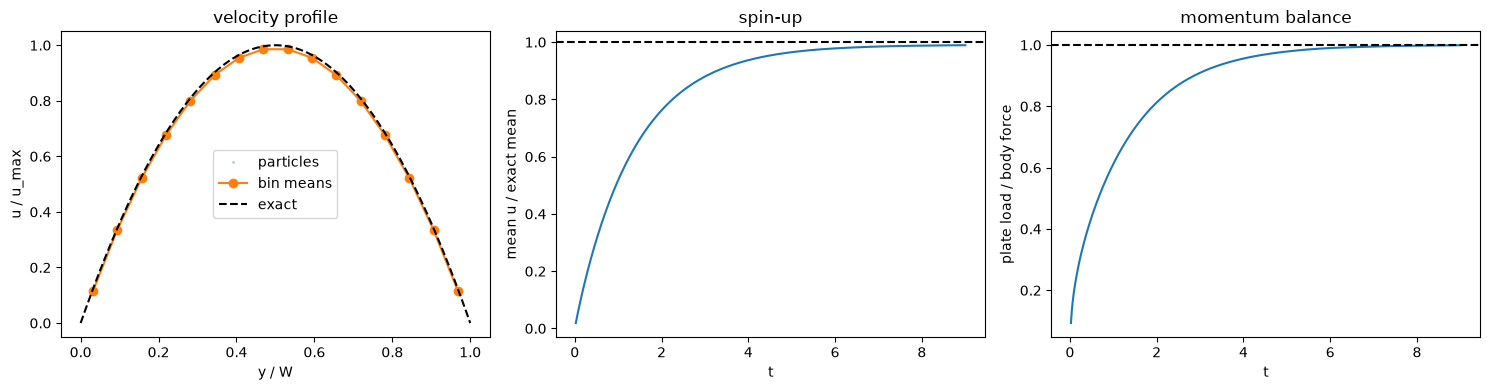

In [5]:
y, u = sol.x[:, 1], sol.v[:, 0]
exact = poiseuille(y, W, f, nu)
amp = float((u * exact).sum() / (exact * exact).sum())
Fbal = f * float(sol.volume.sum())
Fplates = float(np.mean(load[-200:]))
print(f"profile amplitude / parabola = {amp:.4f}")
print(f"plate load / body force on the fluid = {Fplates / Fbal:.4f}")

bins = np.linspace(0, W, 17)
yc = 0.5 * (bins[1:] + bins[:-1])
prof = [u[(y >= a) & (y < b)].mean() / umax for a, b in zip(bins[:-1], bins[1:])]
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(y / W, u / umax, ".", ms=2, alpha=0.3, label="particles"); ax[0].plot(yc / W, prof, "o-", label="bin means")
yy = np.linspace(0, W, 200); ax[0].plot(yy / W, poiseuille(yy, W, f, nu) / umax, "k--", label="exact")
ax[0].set(xlabel="y / W", ylabel="u / u_max", title="velocity profile"); ax[0].legend()
tt, mu = zip(*mean_u); ax[1].plot(tt, mu); ax[1].axhline(1, color="k", ls="--"); ax[1].set(xlabel="t", ylabel="mean u / exact mean", title="spin-up")
ax[2].plot(tt, np.array(load) / Fbal); ax[2].axhline(1, color="k", ls="--"); ax[2].set(xlabel="t", ylabel="plate load / body force", title="momentum balance")
plt.tight_layout(); plt.show()

## What to look at

* amplitude 1 means the wall sits where the geometry says it does (a no-slip plane at $y=0,W$ with the bulk viscosity); the measured deficit of a few per cent is the discretisation error of the closure, first order in the spacing;
* the load ratio closes the momentum balance (1 up to the integration noise); a wall term that leaks momentum shows up here first.